Title: DSC 320 Math for Data Science Assignment 10.2 ; Author: Rachael Biegert ; Date: 24 May 2026 ; Modified By: Rachael Biegert ; Description: This program demonstrates the use of ; NumPy, matplotlib, and scipy to calculate ensemable accuracy using binomial distribution and create a probability mass funciton.

In [28]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

## 1. a)

In [29]:
# Ensemble of 15 models with 63% individual accuracy

# Number of models
n = 15

# Accuracy of each individual model
p = 0.63

# For majority vote with 15 models at least 8 models must be correct
majority = 8

# Calculate probability of getting 8 or more correct predictions
ensemble_accuracy = 1 - binom.cdf(majority - 1, n, p)

print("Ensemble accuracy:", ensemble_accuracy)
print("Ensemble accuracy as percentage:", ensemble_accuracy * 100)

Ensemble accuracy: 0.8512830492077244
Ensemble accuracy as percentage: 85.12830492077244


##b)


In [30]:
# Loop through whole-number percentages
for percent in range(50, 101):

    # Convert percentage to decimal
    p = percent / 100

    # Calculate ensemble accuracy
    ensemble_accuracy = 1 - binom.cdf(7, 15, p)

    # Check if ensemble reaches at least 95%
    if ensemble_accuracy >= 0.95:
        print("Minimum individual model accuracy:", percent, "%")
        print("Ensemble accuracy:", ensemble_accuracy * 100)
        break


Minimum individual model accuracy: 71 %
Ensemble accuracy: 95.86548819437408


##c)

In [31]:
# Individual model accuracy stays fixed at 63%
p = 0.63

# Test odd numbers of models
for n in range(1, 101, 2):

    # Majority threshold
    majority = (n // 2) + 1

    # Calculate ensemble accuracy
    ensemble_accuracy = 1 - binom.cdf(majority - 1, n, p)

    # Check if ensemble reaches at least 95%
    if ensemble_accuracy >= 0.95:
        print("Smallest odd number of models:", n)
        print("Ensemble accuracy:", ensemble_accuracy * 100)
        break

Smallest odd number of models: 39
Ensemble accuracy: 95.18315826463696


## 2. a)


In [32]:
# Possible values of X
x_values = [1, 2, 3, 4, 5]

# Corresponding probabilities
# These must add up to 1
probabilities = [0.10, 0.20, 0.30, 0.25, 0.15]

# Check that probabilities sum to 1
print("Sum of probabilities:", sum(probabilities))



Sum of probabilities: 1.0


##b)

In [33]:
# Function to generate 50 random X-values and return the sample mean
def generate_sample_mean():

    # Randomly generate 50 values from the pmf
    sample = np.random.choice(
        x_values,
        size=50,
        p=probabilities
    )

    # Return the mean of the sample
    return np.mean(sample)


# Test the function once
print("\nOne sample mean:")
print(generate_sample_mean())



One sample mean:
3.22


##c)

In [34]:
# Run the function 1,000 times and store all means in a list
def generate_multiple_means(num_simulations=1000):

    means = []

    # Repeat the sampling process for num_simulations
    for i in range(num_simulations):

        sample_mean = generate_sample_mean()

        means.append(sample_mean)

    return means

# Generate the list of means
means_list = generate_multiple_means()

print("\nFirst 10 sample means:", means_list[:10])


First 10 sample means: [np.float64(3.14), np.float64(3.02), np.float64(2.9), np.float64(2.86), np.float64(3.34), np.float64(3.06), np.float64(3.3), np.float64(3.02), np.float64(3.18), np.float64(3.18)]


##d)

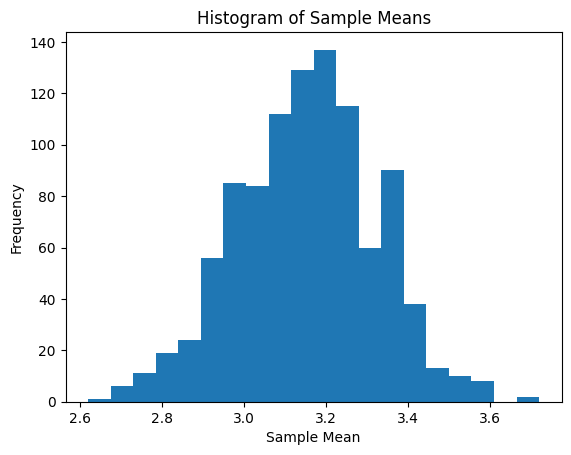

In [35]:
# Create a histogram of the sample means
plt.hist(means_list, bins=20)

# Add labels and title
plt.title("Histogram of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

# Display the histogram
plt.show()

##e)

In [36]:
# Compute experimental and theoretical values

# Experimental mean and standard deviation
experimental_mean = np.mean(means_list)
experimental_std = np.std(means_list)

print("\nExperimental Results")
print("Mean of sample means:", experimental_mean)
print("Standard deviation of sample means:", experimental_std)

# Compute theoretical mean E(X)
theoretical_mean = np.sum(
    np.array(x_values) * np.array(probabilities)
)

# Compute theoretical variance
theoretical_variance = np.sum(
    ((np.array(x_values) - theoretical_mean) ** 2)
    * np.array(probabilities)
)

# Standard deviation of X
theoretical_std_x = np.sqrt(theoretical_variance)

# Standard deviation of sample means
# Central Limit Theorem formula:
# sigma / sqrt(n)
theoretical_std_means = theoretical_std_x / np.sqrt(50)

print("\nTheoretical Results")
print("Theoretical mean:", theoretical_mean)
print("Theoretical standard deviation of means:",
      theoretical_std_means)


Experimental Results
Mean of sample means: 3.15354
Standard deviation of sample means: 0.17097680661423056

Theoretical Results
Theoretical mean: 3.15
Theoretical standard deviation of means: 0.16896745248715803
